<a href="https://colab.research.google.com/github/fedecarboni7/data-projects/blob/main/Reconocimiento_de_Leng_de_Se%C3%B1as.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Presentación del TP

#Inicializaciones

###Código

In [ ]:
# Instalamos la librería rembg para eliminar el fondo de las imagenes
!pip install rembg[gpu]

# Cargamos el modelo para remover el fondo
from rembg import remove, new_session
model_name = "u2net"
session = new_session(model_name)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 50.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.9/52.9 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 12.0 MB/s eta 0:00:00


100%|███████████████████████████████████████| 176M/176M [00:00<00:00, 53.2GB/s]


In [ ]:
# Hacemos los imports
import os
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Realizamos algunas definiciones globales

TAMANIO_IMAGEN = 256
MODEL_PATH     = 'nerdearla.keras'
RUTA_DATA      = "data/"
URL_DESCARGA_DRIVE = 'https://docs.google.com/uc?export=download&id='
COLOR_FONDO_RGBA = (97, 182, 221, 255)

nombres_clases = ['A', 'E', 'I', 'O', 'U']

###Documentación de las Librerías

* [Matplotlib](https://matplotlib.org/)
* [Numpy](https://numpy.org/)
* [PIL](https://pillow.readthedocs.io/en/stable/)
* [Keras](https://keras.io/guides/transfer_learning/)
* [Os](https://docs.python.org/3/library/os.html)
* [Display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html)
* [Rembg](https://pypi.org/project/rembg/)

#Definición de Funciones Auxiliares

###Código

In [ ]:
# Función para tomar un recorte de la esquina superior derecha de la imagen
def recortar_esquina_superior_derecha(filename, tamanio_imagen):
    img = Image.open(filename)
    cropped_img = img.crop((0, 0, tamanio_imagen, tamanio_imagen))
    return cropped_img

# Funcion para sacar una foto
def sacar_foto(ctdad_fotos, ruta_base, nombre_archivo_base, remove_bg=False, cuenta_regresiva=False):
    os.makedirs(ruta_base, exist_ok=True)

    for i in range(ctdad_fotos):
        filename = f'{ruta_base}/{nombre_archivo_base}_{i}.png'
        js = f'''
          async function takePhoto(cuenta_regresiva) {{
            cuenta_regresiva = cuenta_regresiva === "True";
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Sacar foto';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({{video: true}});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            video.style.transform = 'scaleX(-1)'; // Espejamos la imagen
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // Aguardamos que el usuario haga click del botón de Captura
            await new Promise((resolve) => capture.onclick = resolve);

            // Hacer la cuenta regresiva
            if (cuenta_regresiva) {{
              let cuenta_regresiva_texto = ["3", "2", "1"];
              for (let i = 0; i <= 2; i++) {{
                  capture.textContent = cuenta_regresiva_texto[i];
                  await new Promise(resolve => setTimeout(resolve, 1000));
              }}
            }}

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/png');
          }}
          '''
        display(Javascript(js))
        data = eval_js(f'takePhoto("{cuenta_regresiva}");')
        binary = b64decode(data.split(',')[1])
        with open(filename, 'wb') as f:
            f.write(binary)

        clear_output(wait=True)
        print(i+1, '/', ctdad_fotos)

        # Recortamos esquina superior derecha
        cropped_image = recortar_esquina_superior_derecha(filename, TAMANIO_IMAGEN)

        # Removemos el fondo de la imagen
        if remove_bg:
            cropped_image = remove(cropped_image, session=session, bgcolor=COLOR_FONDO_RGBA)

        # Mostramos imagen cortada
        plt.imshow(cropped_image)
        plt.axis('off')
        plt.show()

        # Guardamos imagen recortada
        cropped_image.save(filename)

### Tips para sacar tus mejores fotos

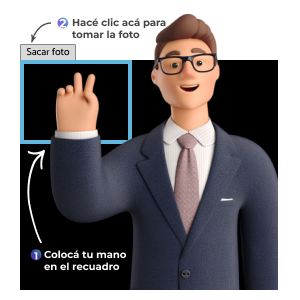

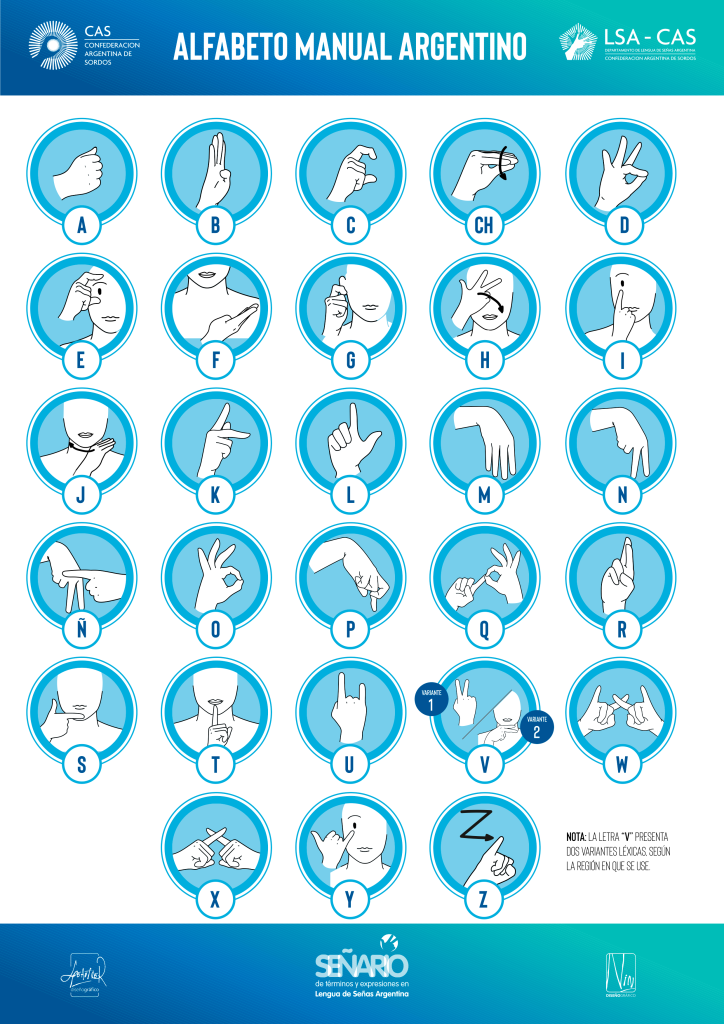

# Copia/generación de las imágenes

### Código

**Opciones de trabajo:**
1. Utilizar imágenes ya procesadas por nosotros
2. Generar tus propias imágenes, utilizando la cámara de tu compu

Para ello seteá la variable "cargar_data_preprocesada" en True o False

In [ ]:
# Podes cargar datos pre-procesados o tomar tus fotos, en dicho caso, asigná False a la variabe cargar_data_procesada
cargar_data_preprocesada = True
if cargar_data_preprocesada:
  try:
    # Bajamos las fotos ya preparadas
    !wget '{URL_DESCARGA_DRIVE}1MxpHZkxpyIxQmYCNkomI6k0wIQolbQdh' -O data.zip
    !unzip -n data.zip
  except:
    print('No se encontró el archivo data.zip')
else:
    # Tomamos fotos nuevas
    n_fotos=10 #Indicamos la cantidad de fotos que queremos sacar

    #print('Recopilando imágenes de letra A:')
    #sacar_foto(ctdad_fotos=n_fotos, ruta_base=RUTA_DATA + 'A', nombre_archivo_base='A', remove_bg=True, cuenta_regresiva=True)

    #print('Recopilando imagenes de letra E:')
    #sacar_foto(ctdad_fotos=n_fotos, ruta_base=RUTA_DATA + 'E' , nombre_archivo_base='E', remove_bg=True, cuenta_regresiva=True)

    print('Recopilando imagenes de letra I:')
    sacar_foto(ctdad_fotos=n_fotos, ruta_base=RUTA_DATA + 'I', nombre_archivo_base='I', remove_bg=True, cuenta_regresiva=True)

    #print('Recopilando imagenes de letra O:')
    #sacar_foto(ctdad_fotos=n_fotos, ruta_base=RUTA_DATA + 'O', nombre_archivo_base='O', remove_bg=True, cuenta_regresiva=True)

  #print('Recopilando imagenes de letra U:')
  #sacar_foto(ctdad_fotos=n_fotos, ruta_base=RUTA_DATA + 'U', nombre_archivo_base='U', remove_bg=True, cuenta_regresiva=True)

    print('Listo!')

--2023-11-26 20:50:47--  https://docs.google.com/uc?export=download&id=1MxpHZkxpyIxQmYCNkomI6k0wIQolbQdh
Resolving docs.google.com (docs.google.com)... 142.251.167.100, 142.251.167.113, 142.251.167.101, ...
Connecting to docs.google.com (docs.google.com)|142.251.167.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0c-9k-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/h73uluesa0806iq70e4t6om7h2njd7mb/1701031800000/06676201329268603781/*/1MxpHZkxpyIxQmYCNkomI6k0wIQolbQdh?e=download&uuid=4c561ec7-ea4e-4398-9103-9fe34856f416 [following]
--2023-11-26 20:50:49--  https://doc-0c-9k-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/h73uluesa0806iq70e4t6om7h2njd7mb/1701031800000/06676201329268603781/*/1MxpHZkxpyIxQmYCNkomI6k0wIQolbQdh?e=download&uuid=4c561ec7-ea4e-4398-9103-9fe34856f416
Resolving doc-0c-9k-docs.googleusercontent.com (doc-0c-9k-docs.googleusercontent.com)... 142.251.163.132, 2607:

###Repaso teórico

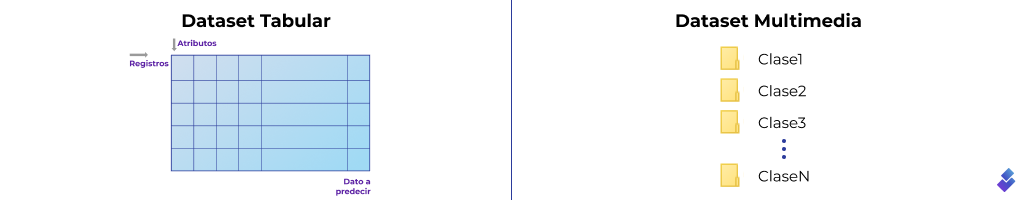

#Preprocesamiento de las imágenes

###Código

100%|██████████| 10/10 [00:00<00:00, 433.13it/s]


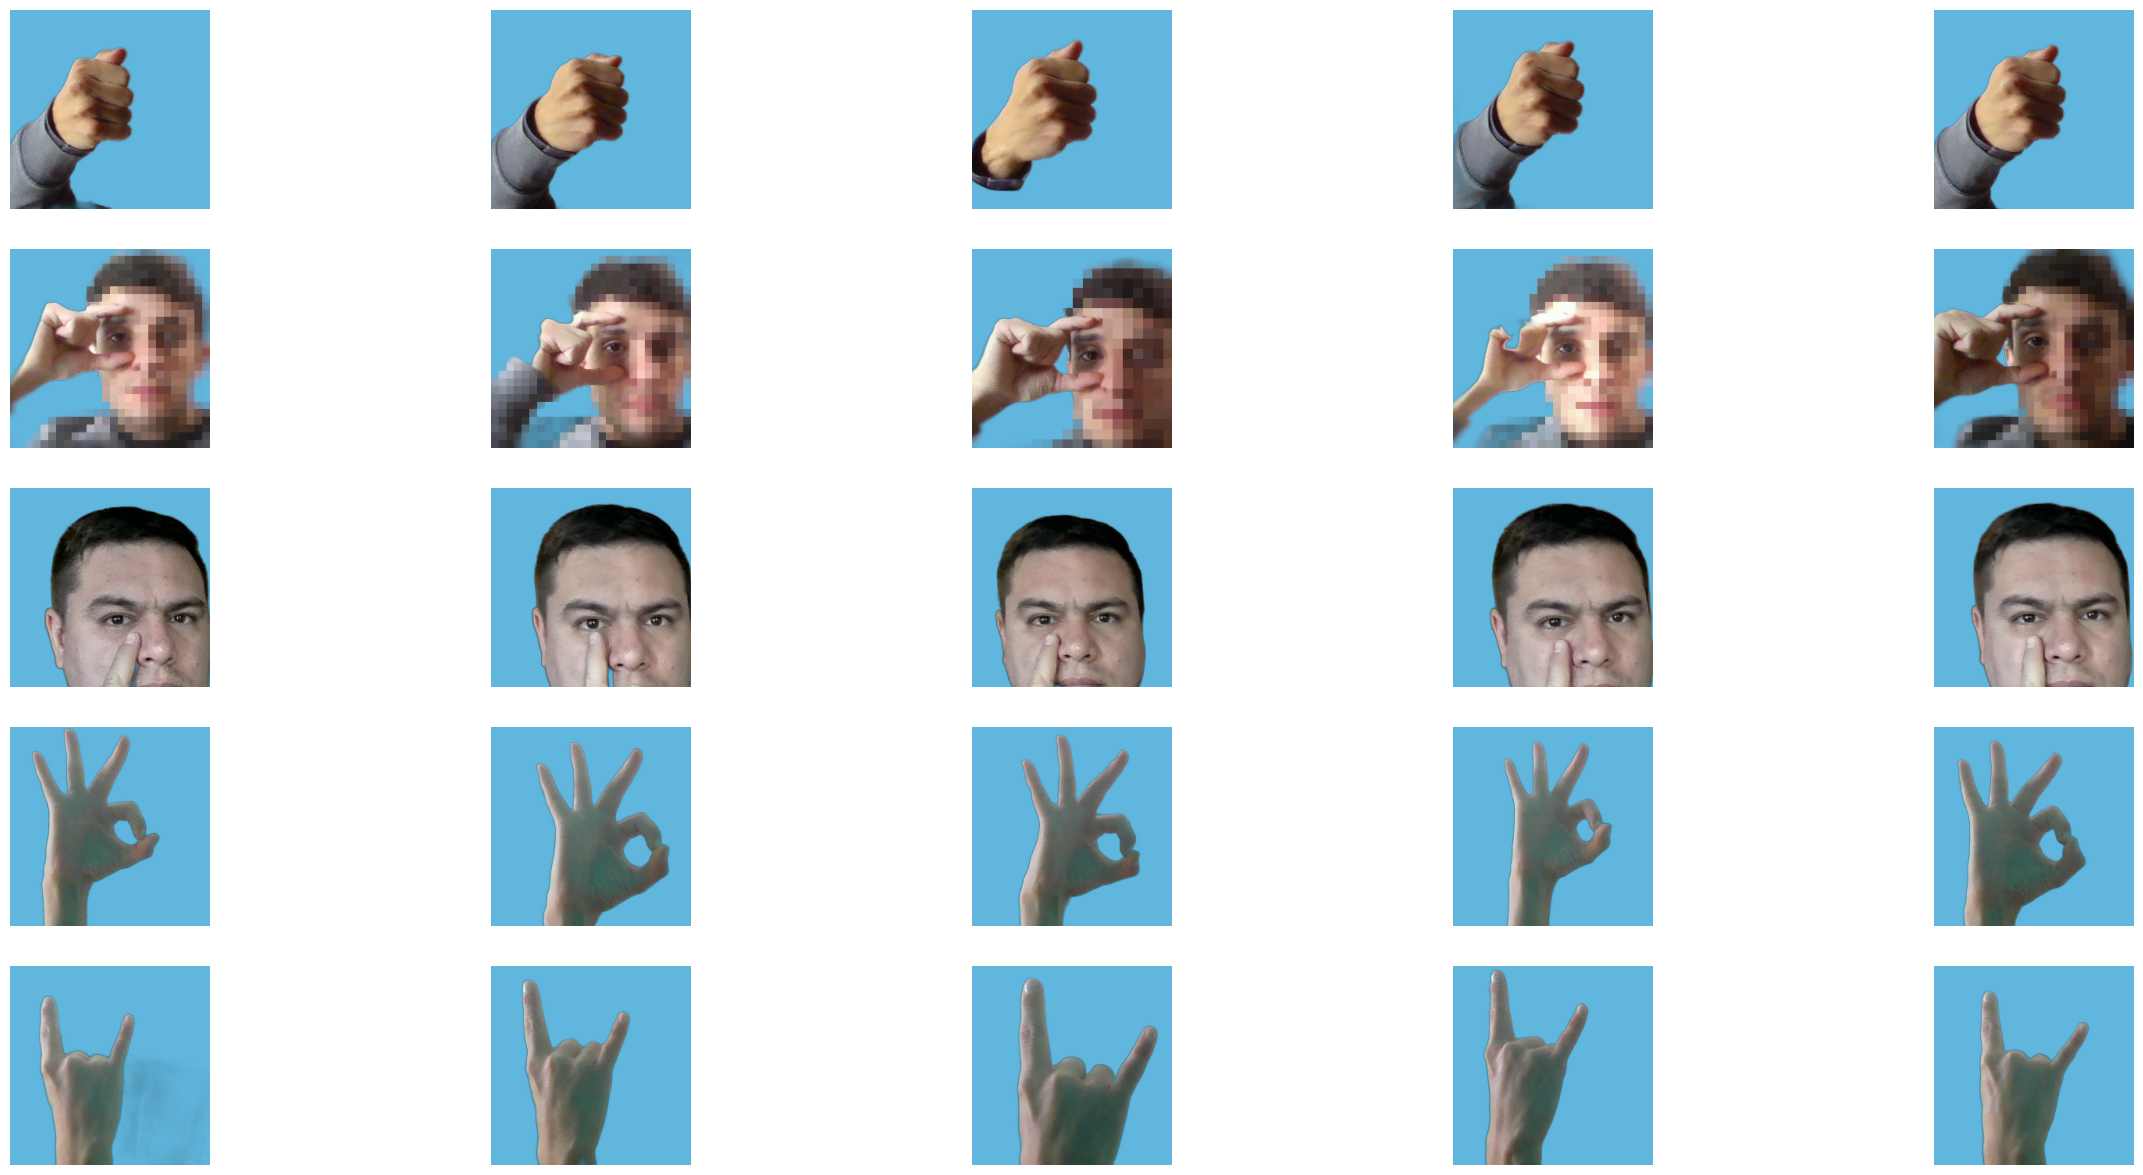

In [ ]:
def leer_datos():

    import os
    from tqdm import tqdm

    letra_A = []
    letra_E = []
    letra_I = []
    letra_O = []
    letra_U = []

    # Recorremos las carpetas de cada clase y leemos las imágenes
    for clase in nombres_clases:
        carpeta = os.path.join(RUTA_DATA, clase)
        for imagen_nombre in tqdm(os.listdir(carpeta)):
            if imagen_nombre[-3:] != 'png': continue
            imagen_path = os.path.join(carpeta, imagen_nombre)
            imagen = Image.open(imagen_path)

            # Pre-procesamos las imágenes nuevas: removemos el fondo y le quitamos el canal de transparencia
            if 'nueva' in imagen_nombre:
              print(f'Removiendo fondo de {imagen_nombre}')
              imagen = remove(imagen, session=session, bgcolor=COLOR_FONDO_RGBA)
              imagen.save(imagen_path)  # Guarda la imagen preprocesada en la misma ubicación
            imagen = np.array(imagen)[:, :, :3]

            # Agregamos a la lista correspondiente en formato tupla (imagen, 'etiqueta')
            if imagen is not None:
                if clase == 'A':
                    letra_A.append([imagen, 'A'])
                elif clase == 'E':
                    letra_E.append([imagen, 'E'])
                elif clase == 'I':
                    letra_I.append([imagen, 'I'])
                elif clase == 'O':
                    letra_O.append([imagen, 'O'])
                elif clase == 'U':
                    letra_U.append([imagen, 'U'])

    # Visualizamos 5 muestras aleatorias de cada clase
    plt.figure(figsize=[30, 15])
    rows, cols = len(nombres_clases), min(len(letra_A), 5)
    for class_index, each_list in enumerate([letra_A, letra_E, letra_I, letra_O, letra_U]):
        r = np.random.choice(np.arange(cols), cols, replace=False);
        for i, example_index in enumerate(r,1):
            plt.subplot(rows,cols,class_index*cols + i )
            plt.imshow(each_list[example_index][0]);
            plt.axis('off');
    plt.show()

    return [letra_A, letra_E, letra_I, letra_O, letra_U]

lista_de_clases = leer_datos()

# Generación del Dataset

###Código

In [ ]:
def preprocesar_datos(lista_de_clases):

    # Separamos las tuplas y armamos 2 listas
    imagenes = []
    etiquetas = []
    for lista in lista_de_clases:
      # Tomamos las imágenes
      imagenes += [tupla[0] for tupla in lista]
      # Tomamos las etiquetas
      etiquetas += [tupla[1] for tupla in lista]

    # Normalizamos los pixeles de las imágenes entre 0 a 1
    imagenes = np.array(imagenes, dtype="float") / 255.0
    etiquetas = np.array(etiquetas)

    # Mostramos los totales
    print('Imagenes totales: {} , Etiquetas totales: {}'.format(len(imagenes), len(etiquetas)))

    # Transformamos las etiquetas de string a one hot encoder
    from sklearn.preprocessing import OneHotEncoder
    codificador_onehot = OneHotEncoder(categories=[nombres_clases], sparse_output=False)
    etiquetas_onehot = codificador_onehot.fit_transform(etiquetas.reshape(-1, 1))
    print(etiquetas[0], etiquetas_onehot[0])

    # Dividimos los datos en entrenamiento y validacion
    from sklearn.model_selection import train_test_split
    imagenes_entrenamiento, imagenes_validacion, etiquetas_entrenamiento, etiquetas_validacion = train_test_split(imagenes, etiquetas_onehot, test_size=0.2, random_state=37, stratify=etiquetas_onehot)

    return imagenes_entrenamiento, imagenes_validacion, etiquetas_entrenamiento, etiquetas_validacion

imagenes_entrenamiento, imagenes_validacion, etiquetas_entrenamiento, etiquetas_validacion = preprocesar_datos(lista_de_clases)

Imagenes totales: 50 , Etiquetas totales: 50
A [1. 0. 0. 0. 0.]


### Repaso Teórico

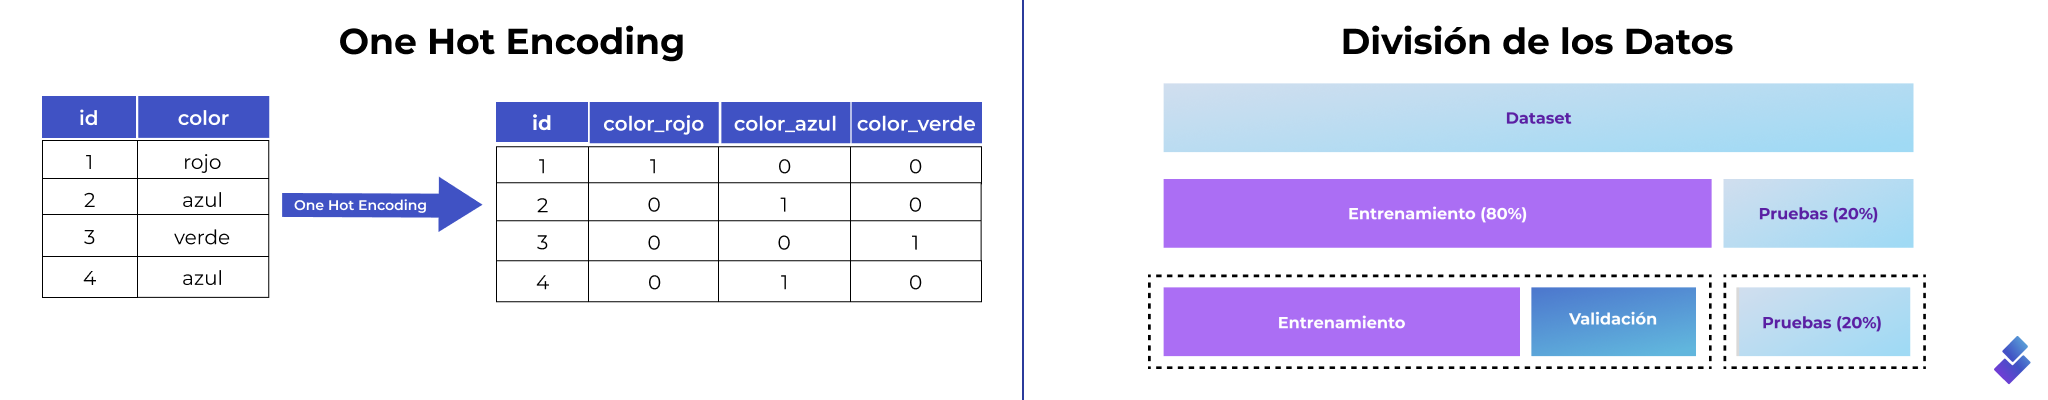

#Generación del Modelo

###Código

**Opciones de trabajo**
1. Utilizar la red pre-entrenada propuesta: DenseNet121
2. Utilizar otra red pre-entrenada: ver la lista en la celda "Redes Alternativas"

In [ ]:
def crear_modelo():

    from keras.applications import DenseNet121
    from keras.layers import Flatten, Dense, Dropout
    from keras.models import Model

    # Cargamos la red neuronal pre-entrenada, sin la capa clasificadora final
    modelo_base = DenseNet121(input_shape=(TAMANIO_IMAGEN, TAMANIO_IMAGEN, 3), include_top=False, weights='imagenet')

    # Congela el modelo base (los pesos)
    modelo_base.trainable = False

    # Añadimoss nuestra última capa clasificadora
    x = modelo_base.output
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.25)(x)
    predicciones = Dense(len(nombres_clases), activation='softmax')(x)

    # Creamos el modelo
    modelo = Model(inputs=modelo_base.input, outputs=predicciones)

    # Compilamos el modelo con la función de optimización y de pérdida elegida
    from keras.optimizers import Adam
    modelo.compile(optimizer=Adam(learning_rate=10**-6), loss='categorical_crossentropy', metrics=['accuracy'])

    return modelo

modelo = crear_modelo()

29084464/29084464 [==============================] - 0s 0us/step


###Repaso Teórico

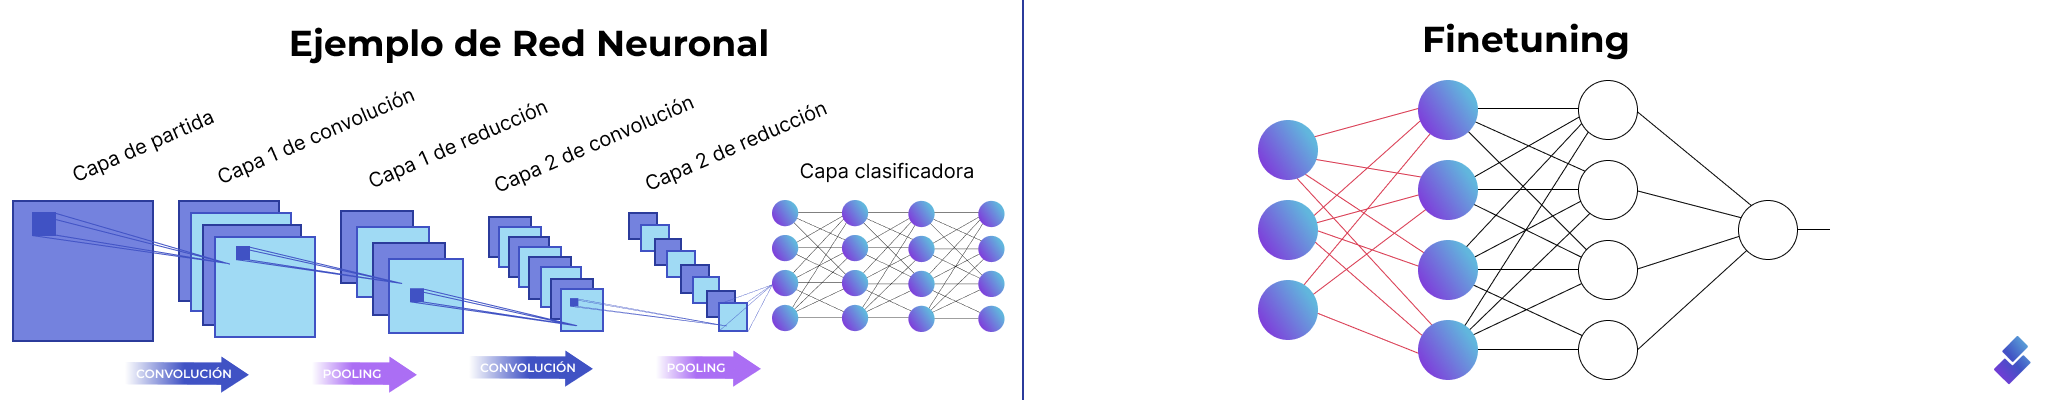

#Entrenamiento del modelo

###Código

**Opciones de trabajo**
1. Modificar cantidad de épocas de entrenamiento
2. Modificar el tamaño del lote
3. No utilizar aumentación de datos

Fotos con data augmentation:


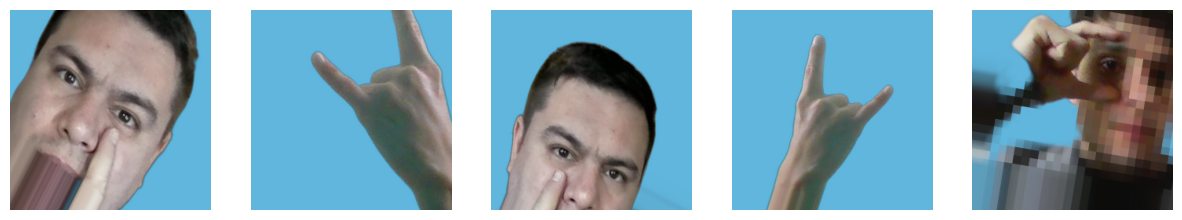

Comenzando entrenamiento...
Epoch 1/5
20/20 [==============================] - 41s 2s/step - loss: 2.5659 - accuracy: 0.2500 - val_loss: 1.6534 - val_accuracy: 0.2000
Epoch 2/5
20/20 [==============================] - 32s 2s/step - loss: 1.4318 - accuracy: 0.3750 - val_loss: 1.3498 - val_accuracy: 0.4000
Epoch 3/5
20/20 [==============================] - 30s 1s/step - loss: 1.3616 - accuracy: 0.5250 - val_loss: 1.0524 - val_accuracy: 0.5000
Epoch 4/5
20/20 [==============================] - 30s 1s/step - loss: 0.9512 - accuracy: 0.6750 - val_loss: 0.8547 - val_accuracy: 0.6000
Epoch 5/5
20/20 [==============================] - 31s 2s/step - loss: 0.8255 - accuracy: 0.6750 - val_loss: 0.7172 - val_accuracy: 0.7000


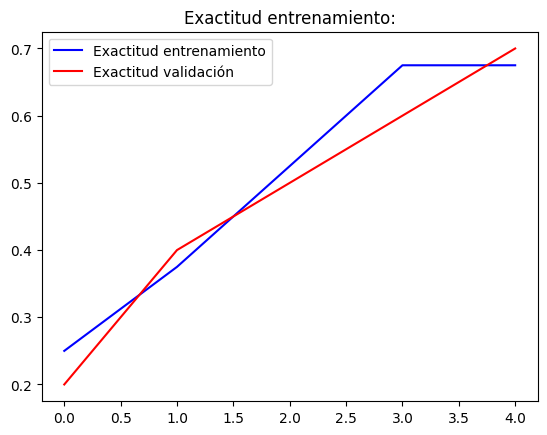

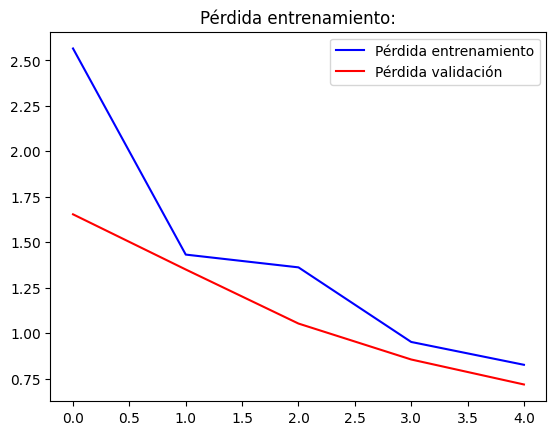

Guardando el modelo como nerdearla.keras...


In [ ]:
def entrenar_modelo(modelo, imagenes_entrenamiento, etiquetas_entrenamiento, imagenes_prueba, etiquetas_prueba):

    from keras.preprocessing.image import ImageDataGenerator

    epochs = 5
    batchsize = 2

    # Definimos la data augmentation
    augmentation = ImageDataGenerator(rotation_range=35, zoom_range=0.2, width_shift_range=0.15, height_shift_range=0.15, shear_range=0.15,
                                      horizontal_flip=True, fill_mode="nearest")
    # augmentation = ImageDataGenerator()    # Esto es para anular el data augmentation
    fotos_augmentation = augmentation.flow(imagenes_entrenamiento, etiquetas_entrenamiento, batch_size=batchsize)

    # Chequeamos cómo quedaron las imágenes aumentadas
    plt.figure(figsize=(15, 5))
    print('Fotos con data augmentation:')
    for i in range(5):
        foto_augmentation = next(fotos_augmentation)[0][0]
        plt.subplot(1, 5, i + 1)
        plt.imshow(foto_augmentation)
        plt.axis('off')
    plt.show()

    # Entrenamos el modelo
    print('Comenzando entrenamiento...')
    #class_weight = {0: 1, 1: 1, 2: 1, 3: 20, 4: 20}
    #historial = modelo.fit(x=fotos_augmentation, validation_data=(imagenes_prueba, etiquetas_prueba), steps_per_epoch= len(imagenes_entrenamiento) // batchsize, epochs=epochs, class_weight=class_weight)
    historial = modelo.fit(x=fotos_augmentation, validation_data=(imagenes_prueba, etiquetas_prueba), steps_per_epoch= len(imagenes_entrenamiento) // batchsize, epochs=epochs)

    # Graficamos la exactitud o accuracy y pérdida de data de entrenamiento y validación
    acc = historial.history['accuracy']
    val_acc = historial.history['val_accuracy']
    loss = historial.history['loss']
    val_loss = historial.history['val_loss']


    # Graficamos las curvas de exactitud o accuracy y de pérdida
    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Exactitud entrenamiento')
    plt.plot(epochs, val_acc, 'r', label='Exactitud validación')
    plt.title('Exactitud entrenamiento:')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Pérdida entrenamiento')
    plt.plot(epochs, val_loss, 'r', label='Pérdida validación')
    plt.title('Pérdida entrenamiento:')
    plt.legend()

    plt.show()

    print(f'Guardando el modelo como {MODEL_PATH}...')
    modelo.save(MODEL_PATH)

    return modelo

modelo = entrenar_modelo(modelo, imagenes_entrenamiento, etiquetas_entrenamiento, imagenes_validacion, etiquetas_validacion)

### Repaso Teórico

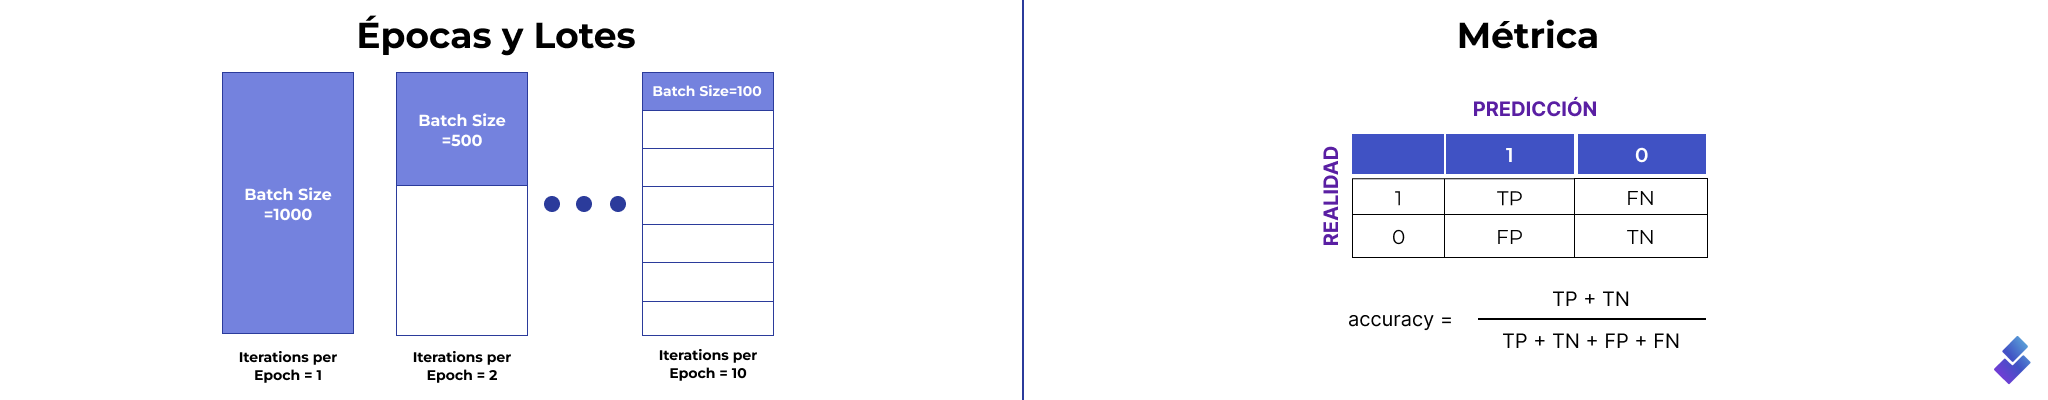

#Probamos?

In [ ]:
# Bajamos imagenes de vocales para probar el modelo
%%capture
!wget '{URL_DESCARGA_DRIVE}1Pc_SCkZRtlKsTxOCIXCLjAgrIhEi4TAY' -O A_pc.png
!wget '{URL_DESCARGA_DRIVE}1U8xpOLh0RAsby6buP_V7poHTLKQCTdyf' -O E_pc.png
!wget '{URL_DESCARGA_DRIVE}1Mm8V8E12wG9-83jQN7kVdTanB-x6L5CG' -O I_pc.png
!wget '{URL_DESCARGA_DRIVE}1G6NbjyraTT_XI1LMdzcVyFzhaHwTGp2E' -O O_pc.png
!wget '{URL_DESCARGA_DRIVE}1jwwwxvTjY4Vsggo4BPHi22GxmES3RLgw' -O U_pc.png

1 / 1


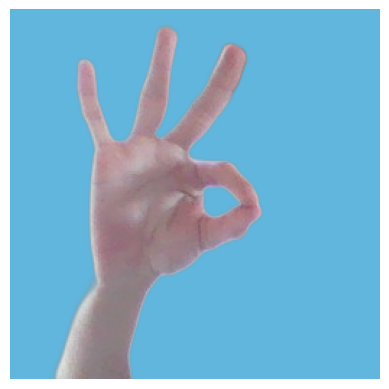

1/1 [==============================] - 0s 218ms/step
Elección usuario: O
[[0.1 0.1 0.  0.6 0.2]]




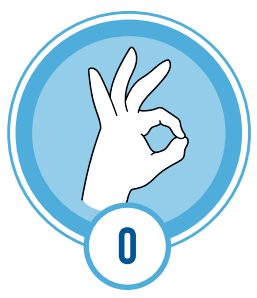


Ingrese algo para continuar:



In [ ]:
def uso_modelo(modelo):

  print('Comenzando prueba...')
  seguir = True
  while seguir:
    # Abrimos cámara y esperamos a que el usuario saque la foto
    sacar_foto(ctdad_fotos=1, ruta_base=RUTA_DATA, nombre_archivo_base='inferencia_nueva', remove_bg=True, cuenta_regresiva=True)

    # Preprocesamos la imágen de la misma manera que las del dataset
    imagen = Image.open(RUTA_DATA + 'inferencia_nueva_0.png')
    imagen = np.array(imagen)[:, :, :3]
    imagen = imagen.astype('float64') / 255.0

    # Usamos el modelo ya entrenado para predecir la clase de esta nueva imagen.
    # Nos devuelve una lista con las probabilidades de las 3 clases
    # Por ejemplo [0.6, 0.1, 0.1, 0.1, 0.1] --> es A
    pred = modelo.predict(imagen.reshape(-1, TAMANIO_IMAGEN, TAMANIO_IMAGEN, 3))

    # Tomamos el índice del elemento máximo dentro de la lista pred
    eleccion_usuario_indice = np.argmax(pred[0])

    # Obtenemos los nombres de las clases de cada uno
    eleccion_usuario = nombres_clases[eleccion_usuario_indice]

    print(f'Elección usuario: {eleccion_usuario.title()}')
    print(pred.round(1))
    print("\n")

    imagen_pc = Image.open(f'{eleccion_usuario}_pc.png')
    display(imagen_pc)

    seguir = input("\nIngrese algo para continuar:\n")

uso_modelo(modelo)

#Redes Alternativas

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Visualizamos las opciones de redes pre-entrenadas disponibles
import pandas as pd
pd.read_html('https://keras.io/api/applications/')[0]